In [36]:
#News Categorization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
#Read the data

df=pd.read_csv('bbc_news_data.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None


In [38]:
#Load the data into X and y

X=df['Text']
y=df['Category']

In [39]:
#View the categories

category_names=df['Category'].unique()
print(category_names)

['business' 'tech' 'politics' 'sport' 'entertainment']


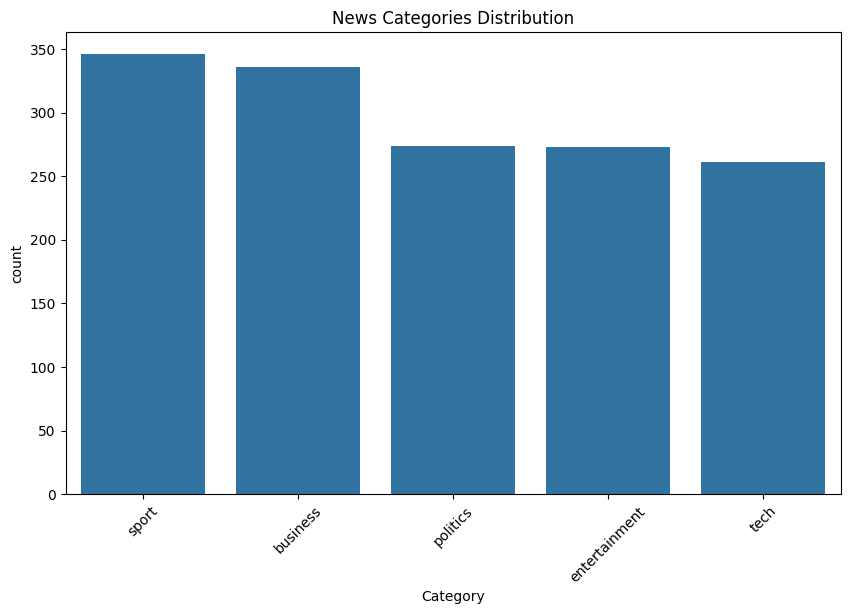

In [40]:
#Categories Distribution

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Category',order=df['Category'].value_counts().index)
plt.xticks(rotation=45)
plt.title("News Categories Distribution")
plt.show()

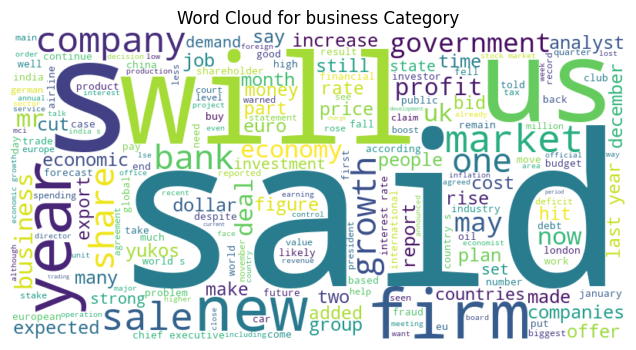

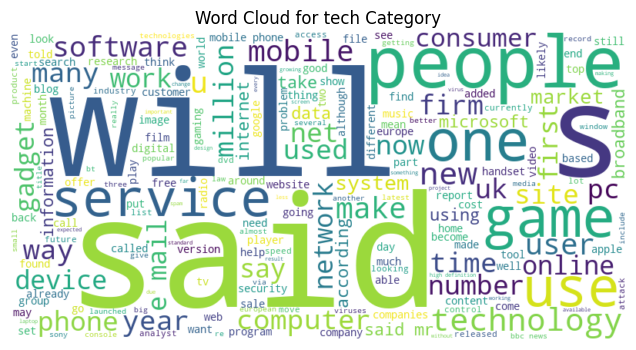

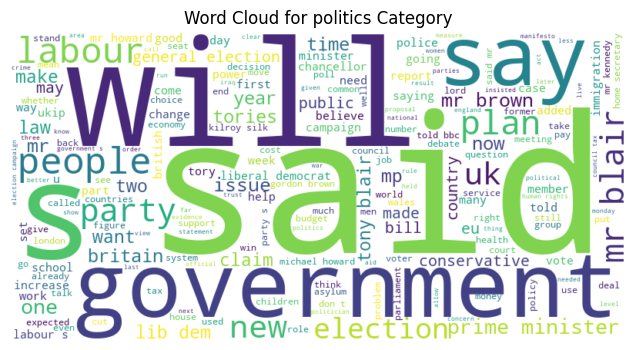

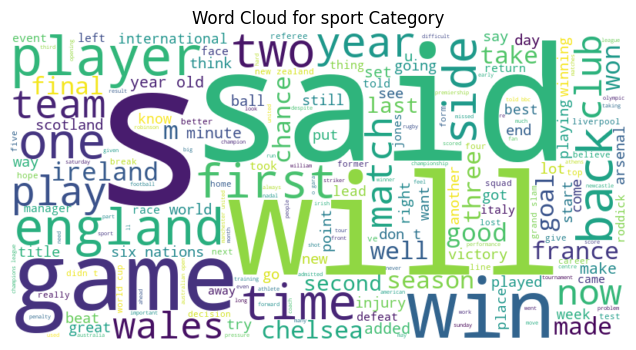

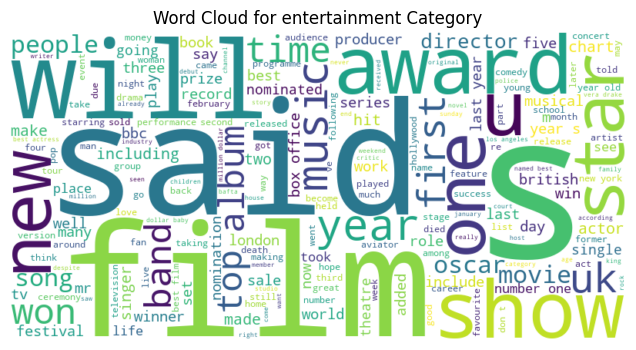

In [41]:
from wordcloud import WordCloud
# Generate a word cloud for each category
for category in category_names:
    text = " ".join(df[df['Category'] ==category]['Text'].values)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {category} Category')
    plt.axis('off')
    plt.savefig(f'WordCloud for {category}.png')
    plt.show()

In [42]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [43]:
#Initialize lemmatizer and stopwords

lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words('English'))
print(stop_words)

{'not', "they've", 'had', 'yourselves', 'being', 'me', 'were', 't', 'they', "he'd", "we'll", 'whom', "she'll", "weren't", 'which', 'against', 'his', 'over', 'into', "wasn't", 'him', 'should', 'so', 'needn', 'now', 'any', 'just', "that'll", 'ain', 'in', 'both', 'below', 'between', "he's", 'our', 'same', 'those', "she'd", 'while', "you'll", 'but', 'than', 're', 'if', "aren't", 'where', 'here', 'down', 'there', 'through', "needn't", 'is', 'their', 'wasn', 'until', 've', 'y', "you've", "i'd", 'under', 'doing', 'won', 'how', 'them', 'very', 'then', 'about', 'before', "he'll", "i've", 'other', "hadn't", 'hasn', 'from', 'yourself', "you're", 'ourselves', 'ours', "mightn't", 'hadn', 'because', 'as', 'this', 'again', "wouldn't", "isn't", 'its', "mustn't", 'why', 'do', 'wouldn', "shouldn't", 'what', 'didn', 'you', 'doesn', 'after', 'll', 'few', 'it', 'mightn', "they'll", 'own', "she's", 'at', 'each', 'hers', 'does', 'with', 'are', 'such', 'off', 'can', 'having', 'have', 's', 'no', 'to', 'during'

In [44]:
lemmatizer.lemmatize(word='sleeping',pos='v')

'sleep'

In [45]:
def preprocess_text(text):

    #Lowercasing
    text=text.lower()

    #Removing special characters and puntuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    #Tokenization
    words=word_tokenize(text)

    #Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join back into a string
    return ' '.join(words)
    

In [46]:
#Apply the function to a sample text

text="Hey there! It's so gooood to see you!! :)"
print(preprocess_text(text))

hey gooood see


In [47]:
#Apply preprocessing function 
df['Text']=df['Text'].apply(preprocess_text)

In [48]:
X=df['Text']
y=df['Category']

In [51]:
#Split the dataset into training and testing

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [57]:
#Create a pipeline for News Caterogization using Naive Bayes

from sklearn.pipeline import make_pipeline
nb_model =make_pipeline(TfidfVectorizer(stop_words='english'),MultinomialNB())
nb_model.fit(X_train,y_train)
y_pred_nb=nb_model.predict(X_test)
print(f'Accuracy={accuracy_score(y_true=y_test,y_pred=y_pred_nb)*100:.2f}')

Accuracy=96.31


In [59]:
news_texts=[
    "The latest football match ended in a draw,with great performances from both"
]
new_predictions=nb_model.predict(news_texts)

for text,prediction in zip(news_texts,new_predictions):
    print(f'Text:{text}\nPredicted Category:{prediction}')

Text:The latest football match ended in a draw,with great performances from both
Predicted Category:sport


In [60]:
import joblib
joblib.dump(nb_model,'nb_model.joblib')
print('SUCCESS')

SUCCESS
